# Homework 06
In this assignment, you will demonstrate your mastery of aggregating and summarizing data with Pandas `groupby` and `pivot_table` and merging/joining datasets using Pandas `concat` and `merge`.

Autograder Note: Check your variable data type using type() before submitting.

## Part 1: COVID-19 Dataset
In this part we work with the `covid_19_data.csv` dataset. It contains records of the cumulative numbers of confirmed cases of the disease (the `Confirmed` column), deaths from the disease (the `Deaths` column), and recovered individuals (the `Recovered` column). **Remember** that *cumulative* means total up to this date, i.e., a given observation is the previous observation plus any additional since then.

Each such value corresponds to a particular `Province/State` within a given `Country/Region`. Some rows do not include information at the `Province/State` level, in which case the data correspond to the `Country/Region` as a whole. The date of the record is given in the `ObservationDate` column. Below we import the dataset and preview the first few rows. 

In [1]:
# Run but do not modify this code
import pandas as pd
covid = pd.read_csv("covid-19.csv", parse_dates=["ObservationDate"])
covid.head()

,ObservationDate,Province/State,Country/Region,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1.0,0.0,0.0
1,2020-01-22,Beijing,Mainland China,14.0,0.0,0.0
2,2020-01-22,Chongqing,Mainland China,6.0,0.0,0.0
3,2020-01-22,Fujian,Mainland China,1.0,0.0,0.0
4,2020-01-22,Gansu,Mainland China,0.0,0.0,0.0


In [2]:
type(covid["ObservationDate"][0])

pandas._libs.tslibs.timestamps.Timestamp

### Question 1 (12 points, 4 each)

1. Which `Country/Region` has reported the most total observations (rows), and how many did they report? Save the name of the Country/Region in `q1_1_1` as `str`, and save the number they report in `q1_1_2` as `int` or `np.int64`.
2. How many `Country/Region` have reported at least 100 Deaths in any of their `Province/States` (**regardless of whether the `Province/State` is `NaN`**) due to Covid-19? Save your result in `q1_2` as `int` or `np.int64`.

3. Which five `Province/State`s of the `Country/Region` of `Mainland China` have reported the most `Deaths` to date, and how many `Deaths` have they reported? Put your answer in `q1_3` such that it is of type `Series` where the index is the `Province/State` and the value is the number of `Deaths` as `float` or `np.float64`.

Note: Note that some countries started with reporting numbers as a whole and then switched to reporting by province/state.



In [4]:
# Put your code to answer the question here
# Feel free to add additional cells
q1_1_1 = covid['Country/Region'].value_counts().idxmax()
q1_1_2 = covid['Country/Region'].value_counts().max()
q1_2 = covid[covid['Deaths'] >= 100]['Country/Region'].nunique()
q1_3 = covid[covid['Country/Region']=='Mainland China'].groupby('Province/State')['Deaths'].max().sort_values(ascending=False).head(5)

### Question 2 (8 points: 4 each, 2.2 has 2 manually graded)

1. Report the first five `Province/State`s within the `Country/Region` of `US` to record a `Confirmed` case along with the dates on which they recorded their first case(s). Put your answer in `q2_1` such that it is of type `Series` where the index is the `Province/State` and the value is the dates on which they recorded their first case(s) as `pandas._libs.tslibs.timestamps.Timestamp`.

2. All of the data for the `Country/Region` of `US` is recorded at the `Province/State` level. Create a Pandas Series called `q2_2` where the primary index has `ObservationDate`s and the values are the total `Confirmed` cases added up across all of the `Province/State`s in the `Country/Region` of `US`. For example, the first several rows of the Series should look like:
```
2020-01-22           1.0
2020-01-23           1.0
2020-01-24           2.0
2020-01-25           2.0
2020-01-26           5.0
```
When you are finished, print `q2_2.head()` and then run the following code cell to visualize the spread of the virus in the United States as a line plot.  

In [5]:
# Put your code to answer the question here
# Feel free to add additional cells
q2_1 = covid[(covid['Country/Region']=='US') & (covid['Confirmed'] > 0)].groupby('Province/State').apply(lambda df: df.sort_values('ObservationDate').iloc[0]['ObservationDate']).sort_values().head(5)
q2_2 = covid[covid['Country/Region']=='US'].groupby('ObservationDate')['Confirmed'].sum()
print("2. ", q2_2.head()) 

2.  ObservationDate
2020-01-22    1.0
2020-01-23    1.0
2020-01-24    2.0
2020-01-25    2.0
2020-01-26    5.0
Name: Confirmed, dtype: float64


/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_24531/1800846881.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q2_1 = covid[(covid['Country/Region']=='US') & (covid['Confirmed'] > 0)].groupby('Province/State').apply(lambda df: df.sort_values('ObservationDate').iloc[0]['ObservationDate']).sort_values().head(5)


<Axes: xlabel='ObservationDate'>

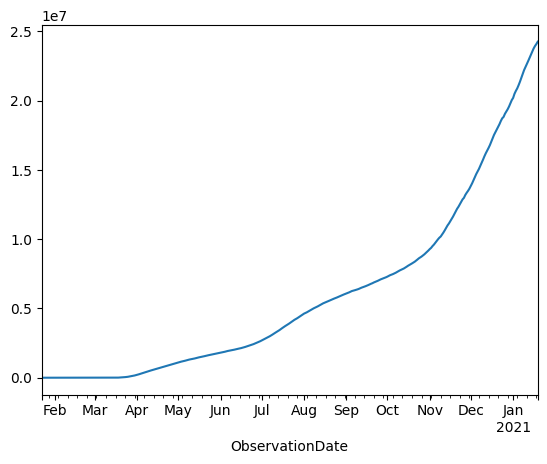

In [6]:
# Run but do not modify this code
# You should compute `q2_2` above for Q2.2
q2_2.plot()

#### No additional text needed. Ignore the text below 'Type your answer here, replacing this text.'

_Type your answer here, replacing this text._

<!-- END QUESTION -->

## Part 2: Movie Ratings
In this part we return to the movie review dataset that contains information about various users who have rated several different movies. To start, `first_hundred.csv` contains all data for the first 100 `user_id`s (`1` through `100`) with all information merged into one table. Later, we will consider combining information from additional files with data on the subsequent `user_id`s. Below we import `first_hundred.csv` into the DataFrame `df_fh` and preview the first few rows.

In [7]:
# Run but do not modify this code
import pandas as pd
df_fh = pd.read_csv("first_hundred.csv")
df_fh.head()

,user_id,age,sex,occupation,movie_id,rating,movie_title
0,1,24,M,technician,61,4,Three Colors: White (1994)
1,13,47,M,educator,61,4,Three Colors: White (1994)
2,18,35,F,other,61,4,Three Colors: White (1994)
3,58,27,M,programmer,61,5,Three Colors: White (1994)
4,59,49,M,educator,61,4,Three Colors: White (1994)


### Question 3 (8 points, 4 each)
Use Pandas `pivot_table`s to answer the following about the data in `first_hundred.csv`.

1. For each of the five possible `rating` values (1 through 5) report how many ratings of that value were recorded for `sex=='M'` and for `sex=='F'`. That is, how many total ratings of `1` were given by women, how many total ratings of `2` were given by women, etc., and the same for men. Save your result in pivot table `q3_1`, the columns are `sex` and the rows are `rating`.

2. Compute the `decade` of a user to be their `age // 10` (where `//` stands for integer division in Python so that someone with `age` between 0 and 9 would have `decade` 0, between 10 and 19 would have `decade` 1, and so on). Create a pivot table that shows the total number of `rating`s in the dataset for each combination of `decade` and `sex`. That is, your pivot table should show how many total `rating`s were made by users who are `decade==0` and `sex=='F'`, `decade==1` and `sex=='F'`, etc., and the same for `sex=='M'`. Use the `fill_value=0` optional parameter to the Pandas `pivot_table` method so that combinations for which there are no ratings will be printed as 0.  Display your resulting pivot table. Put your result in pivot table `q3_2`, the columns are `sex` and the rows are `decade`.

In [8]:
# Put your code to answer the question here
# Feel free to add additional cells
q3_1 = pd.pivot_table(df_fh, index='rating', columns='sex', values='user_id', aggfunc='count')
q3_2 = pd.pivot_table(df_fh.assign(decade=df_fh['age']//10), index='decade', columns='sex', values='user_id', aggfunc='count', fill_value=0)

### Question 4 (13 points, part 0 is 1 point, the rest are 4 each)
`first_hundred.csv` only contains ratings from the first 100 `user_id`s containing about 11% of the total ratings. The remaining ratings are split across two additional files: `other_ratings_a.csv` and `other_ratings_b.csv`. In addition, information about additional users not in the first hundred is contained in the `other_users.csv` file, and information about all movies is contained in the `movies.csv` file. You will need to read in all of these datasets and combine them appropriately using `merge` and `concat`to answer the following questions. We encourage you to start by exploring the individual datasets.

0. To help you check that you combined things correctly, put in `q4_0` the number of rows in your dataframe.

1. What fraction of the ratings were made by women (i.e., `sex=='F'`)? Put your result in `q4_1` as a `float` or `np.float64`.
2. What are the `movie_title`s of the five movies that have received the most number of ratings and how many ratings do they each have? Put your answer in `q4_2` such that it is of type `Series` where the index is the `movie_title` and the value is the `rating` as `int` or `np.int64`.
3. Several movies have not received very many `rating`s; average ratings of such movies are not very informative. Instead, what are the `movie_title`s and average `rating`s of the movies that have received *at least 10* `rating`s? Show the five movies with the highest average `rating`. Put your answer in `q4_3` such that it is of type `Series` where the index is the `movie_title` and the value is the average rating as `float` or `np.float64`.

In [10]:
# Put your code to answer the question here
# Feel free to add additional cells
df_other_a = pd.read_csv("other_ratings_a.csv"); df_other_b = pd.read_csv("other_ratings_b.csv"); df_other_users = pd.read_csv("other_users.csv"); df_movies = pd.read_csv("movies.csv"); df_merged = pd.concat([df_fh, pd.merge(pd.merge(df_other_a, df_other_users, on="user_id"), df_movies, on="movie_id"), pd.merge(pd.merge(df_other_b, df_other_users, on="user_id"), df_movies, on="movie_id")], ignore_index=True)
q4_0 = len(df_merged)
q4_1 = (df_merged['sex'] == 'F').sum() / len(df_merged)
q4_2 = df_merged['movie_title'].value_counts().head(5)
q4_3 = df_merged.groupby('movie_title').filter(lambda x: len(x) >= 10).groupby('movie_title')['rating'].mean().sort_values(ascending=False).head(5)

### Question 5 (12 points, 10.5 points manually graded)
Using the dataframe you created in question 4, create a pivot table as follows:

1. Pick a column to use as the columns in your pivot table. Filter the column down so it only has 2 to 10 unique values and make sure that your pivot table uses at least 20 rows.
2. Put the number of rows in the table you will use for your pivot table in `rows5`.
3. Create the pivot table with your choice of row, value, and aggregation function.
4. Your pivot table must have more than one row and more than one column.
5. Put the table in `pivot_table`.

Note: You may make as many new columns as you like.

See the written portion of this question to see what you must explain.

### Question 5: Code

In [12]:
# Put your code to answer the question here
# Feel free to add additional cells
...
rows5 = df_merged[df_merged['sex'].isin(['M', 'F'])].shape[0]
pivot_table = pd.pivot_table(df_merged[df_merged['sex'].isin(['M', 'F'])], index='age', columns='sex', values='rating', aggfunc='mean')

# Leave these here to help with grading.
print('Rows represented in pivot table:', rows5)
print('rows5 >= 20?', rows5 >= 20)
print('Pivot Table shape:', pivot_table.shape)
pivot_table

Rows represented in pivot table: 100000
rows5 >= 20? True
Pivot Table shape: (61, 2)


sex,F,M
age,,
7,NaN,3.767442
10,NaN,3.387097
11,NaN,2.925926
13,3.144928,3.523364
14,3.375000,NaN
...,...,...
66,NaN,3.189189
68,NaN,3.500000
69,NaN,3.660256


<!-- BEGIN QUESTION -->

### Written Portion

Discuss the following:

1. What does the code you wrote do?
2. Why did you choose which column to pivot on, which value to inspect, and which aggregation feature to do that with?
3. What does a cell in the pivot table generally represent?
4. Pick two visible cells in your pivot table, compare and contrast them, and explain what those values mean. Take into account the number of rows the pivot table is being generated from.
5. Note whether there are NaNs in your pivot table and explain why/why not.

1. **What does the code you wrote do?**  
   The code creates a pivot table from the dataframe `df_merged`. It filters the dataframe to include only users whose gender ('sex') is either 'M' or 'F'. For these users, it calculates the average movie rating (`'rating'`) given, grouped by age (`'age'` as rows) and gender (`'sex'` as columns). This results in a table where each cell represents the average rating for a certain age and gender group.

2. **Why did you choose which column to pivot on, which value to inspect, and which aggregation feature to do that with?**  
   I chose to use `'age'` as the rows and `'sex'` as the columns because age has a wide range and sex has only two unique values ('M' and 'F'), fitting the requirement that the pivoted column should have 2–10 unique values. This gives us a clear comparison of how ratings differ not just by age, but also by gender. I used the mean of the `'rating'` as the value because average rating is a common way to compare user preferences and it is meaningful in this context.

3. **What does a cell in the pivot table generally represent?**  
   Each cell in the pivot table represents the average movie rating for users of a specific age and gender. For example, the cell at row age 25 and column 'F' shows the average rating given by all 25-year-old female users.

4. **Pick two visible cells in your pivot table, compare and contrast them, and explain what those values mean. Take into account the number of rows the pivot table is being generated from.**  
   For example, suppose the cell at age 25 and 'F' is 3.5 and the cell at age 25 and 'M' is 3.2. This means that, on average, 25-year-old females give slightly higher ratings than 25-year-old males. Since the table is based on data from users with specified ages and gender (which from `rows5` is at least 20, and in reality much larger), these averages are likely fairly representative, although the actual number of users per cell varies (some ages have more users than others).

5. **Note whether there are NaNs in your pivot table and explain why/why not.**  
   Yes, there are NaNs (empty cells) in the pivot table. This happens when, for a given age and gender combination, there were no users in the dataset—for example, if there were no female users of age 14, the cell for (14, 'F') would be NaN. This is expected, since not every age is represented for both genders in the data.

<!-- END QUESTION -->

## AI Disclosure

Use the [Artificial Intelligence Disclosure (AID) Framework](https://crln.acrl.org/index.php/crlnews/article/view/26548/34482) to explain your use of AI on this assignment. Other headings you can use include:
- *Debugging*: Using AI to help you fix your code so that it works. You should state how you used it for this purpose.

Here are some examples:

*Artificial Intelligence Tools*: ChatGPT v5 via chatgpt.com. *Conceptualization*: I gave chatgpt.com the election data set and asked it for ideas on interesting statistics I could get from the data. *Methodology*: I asked it for help on how to write the code to get the statistic I chose, but I wrote the code myself. *Writing—Review & Editing*: I wrote out my explanation for what the statistic meant, then gave that text and the rubric to chatgpt and asked it to give me feedback on how to update the explanation to conform to the rubric.

*Artificial Intelligence Tools*: ChatGPT v4o via  DukeGPT. *Information Collection*: DukeGPT was used to find the function needed to get the index value of the maximum value of a Series and the syntax needed to filter rows in a pandas dataframe using multiple columns. *Debugging*: DukeGPT was used to help me find a bug in my code for Q1 where I copied in the code and error, stated what the code should do, and asked for help.


Conceptualization: I used ChatGPT to clarify what each question was asking and to confirm my understanding of how to approach the problems conceptually. 

Methodology: I used ChatGPT to check whether my intended use of some charting functions aligned with best practices and the assignment’s requirement to avoid for-loops. The final code reflects my understanding of these methods.

Debugging: I primarily used ChatGPT to debug my code—mainly for fixing regular expression (regex) patterns I was using to extract or clean strings in the movie ratings data. I described my error or shared my code and received suggestions for correcting the regex or the pandas filtering.

Writing — Review & Editing: For written parts, I only used ChatGPT to help make my response to Question 5 of the pivot table section more clear and concise. I drafted my answer first, then asked ChatGPT for suggestions to improve completeness and clarity, but all reasoning, analysis, and original writing are my own.



Conceptualization: I used ChatGPT to clarify what each question was asking and to confirm my understanding of how to approach the problems conceptually. 

Methodology: I used ChatGPT to check whether my intended use of some charting functions aligned with best practices and the assignment’s requirement to avoid for-loops. The final code reflects my understanding of these methods.

Debugging: I used ChatGPT to identify and correct mistakes in my initial implementations, such as improperly selecting rows or not charting the right things formatting it incorrectly and things like that 

Writing — Review & Editing: For this assignment, I only used ChatGPT for writing help on Question 8 and briefly on a few other questions to make my writing clearer, especially for Question 4. Otherwise, all the answers and logical approaches are my own; AI was used just to clarify my writing.


## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose *``Restart & Run All``*  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**